# Crime Data Analysis and Risk Prediction using Machine Learning

## Project Objective
This project analyzes NCRB crime statistics across Indian states using data cleaning, feature engineering, exploratory data analysis, and machine learning. The goal is to identify crime patterns and predict crime risk levels using historical crime and demographic indicators.


## Project Workflow

**1️⃣ Data Collection**
- NCRB Crime Tables (Tabula extraction)
- Population Dataset
- Women Crime Dataset

⬇️

**2️⃣ Data Cleaning & Preprocessing**
- Remove header noise
- Standardize state names
- Convert numeric columns

⬇️

**3️⃣ Data Integration**
- Merge crime, population, and women crime data
- Create unified analytical dataset

⬇️

**4️⃣ Feature Engineering**
- Women Crime Percentage
- Crime Risk Categories (Low / Medium / High)

⬇️

**5️⃣ Exploratory Data Analysis**
- Crime trends across states
- Crime rate comparisons
- Chargesheet and women crime analysis

⬇️

**6️⃣ Machine Learning Modeling**
- Random Forest Classifier
- Train–Test Split
- Accuracy Evaluation

⬇️

**7️⃣ Model Interpretation**
- Feature Importance Analysis

⬇️

**8️⃣ Interactive Prediction**
- User inputs state name
- Model predicts crime risk level


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
sns.set_palette("muted")


## Data Loading
The crime dataset extracted using Tabula, population statistics, and women-related crime data are loaded for further preprocessing.


In [2]:
df = pd.read_csv("ipc_sll_statewise.csv", header=None)
df.head()


,0,1,2,3,4,5,6,7
0,NaN,NaN,NaN,NaN,NaN,NaN,Rate of,NaN
1,NaN,NaN,NaN,NaN,NaN,Mid-Year,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,Cognizable,Chargesheeti
3,NaN,NaN,NaN,NaN,NaN,Projected,NaN,NaN
4,SL State/UT,NaN,2020,2021,2022,NaN,Crimes,ng Rate


## Data Cleaning and Preprocessing
In this section, irrelevant rows are removed, column names are standardized, numerical values are converted, and state names are cleaned to enable accurate merging.


In [3]:
df = df.dropna(how="all")
df = df.reset_index(drop=True)


In [4]:
df.head(10)


,0,1,2,3,4,5,6,7
0,NaN,NaN,NaN,NaN,NaN,NaN,Rate of,NaN
1,NaN,NaN,NaN,NaN,NaN,Mid-Year,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,Cognizable,Chargesheeti
3,NaN,NaN,NaN,NaN,NaN,Projected,NaN,NaN
4,SL State/UT,NaN,2020,2021,2022,NaN,Crimes,ng Rate
5,NaN,NaN,NaN,NaN,NaN,Population (in,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,(IPC+SLL),(2022)
7,NaN,NaN,NaN,NaN,NaN,Lakhs) (2022),NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,(2022),NaN
9,[1] [2],NaN,[3],[4],[5],[6],[7],[8]


In [5]:
df = pd.read_csv("ipc_sll_statewise.csv", header=None, skiprows=10)


In [6]:
df.head()


,0,1,2,3,4,5,6,7
0,STATES:,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1 Andhra Pradesh,NaN,238105.0,222199.0,195284.0,530.3,368.2,88.9
2,2 Arunachal Pradesh,NaN,2503.0,3039.0,2761.0,15.5,178.0,51.9
3,3 Assam,NaN,121609.0,133239.0,68937.0,354.9,194.2,34.3
4,4 Bihar,NaN,257512.0,282083.0,347835.0,1255.3,277.1,82.5


In [7]:
df = df[df[0] != "STATES:"]
df = df.reset_index(drop=True)


In [8]:
df.columns = [
    "State",
    "Unused",
    "Crime_2020",
    "Crime_2021",
    "Crime_2022",
    "Population_Lakh_2022",
    "Crime_Rate_2022",
    "Chargesheet_Rate_2022"
]


In [9]:
df = df.drop(columns=["Unused"])


In [10]:
df["State"] = df["State"].str.replace(r'^\d+\s*', '', regex=True)
df["State"] = df["State"].str.strip()


In [11]:
num_cols = [
    "Crime_2020",
    "Crime_2021",
    "Crime_2022",
    "Population_Lakh_2022",
    "Crime_Rate_2022",
    "Chargesheet_Rate_2022"
]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")


In [12]:
print(df.head())


               State  Crime_2020  Crime_2021  Crime_2022  \
0     Andhra Pradesh    238105.0    222199.0    195284.0   
1  Arunachal Pradesh      2503.0      3039.0      2761.0   
2              Assam    121609.0    133239.0     68937.0   
3              Bihar    257512.0    282083.0    347835.0   
4       Chhattisgarh    103173.0    110633.0    121065.0   

   Population_Lakh_2022  Crime_Rate_2022  Chargesheet_Rate_2022  
0                 530.3            368.2                   88.9  
1                  15.5            178.0                   51.9  
2                 354.9            194.2                   34.3  
3                1255.3            277.1                   82.5  
4                 299.5            404.2                   87.9  


In [13]:
pop_df = pd.read_excel("population_census_2011.xlsx")
pop_df.head()


,State,District,Subdistt,Town/Village,Ward,EB,Level,Name,TRU,No_HH,...,MARG_AL_0_3_F,MARG_HH_0_3_P,MARG_HH_0_3_M,MARG_HH_0_3_F,MARG_OT_0_3_P,MARG_OT_0_3_M,MARG_OT_0_3_F,NON_WORK_P,NON_WORK_M,NON_WORK_F
0,0,0,0,0,0,0,India,India,Total,249501663,...,5820403,1420348,491424,928924,5518450,3082613,2435837,728966109,291330383,437635726
1,0,0,0,0,0,0,India,India,Rural,168612897,...,5640822,1154975,386077,768898,3803400,1972348,1831052,485005760,200944045,284061715
2,0,0,0,0,0,0,India,India,Urban,80888766,...,179581,265373,105347,160026,1715050,1110265,604785,243960349,90386338,153574011
3,1,0,0,0,0,0,STATE,JAMMU & KASHMIR,Total,2119718,...,44570,26585,6780,19805,108457,56880,51577,8218589,3445572,4773017
4,1,0,0,0,0,0,STATE,JAMMU & KASHMIR,Rural,1553433,...,40936,21963,5757,16206,89232,45625,43607,5994979,2562471,3432508


In [14]:
pop_df = pop_df[["Name", "TOT_P"]]
pop_df.columns = ["State", "Population_2011"]


In [15]:
df["State"] = df["State"].str.strip().str.lower()
pop_df["State"] = pop_df["State"].str.strip().str.lower()


## Data Integration
Crime data & population data are merged to create a unified dataset for analysis and modeling.


In [16]:
merged_df = pd.merge(
    df,
    pop_df,
    on="State",
    how="left"
)


In [17]:
print(merged_df.head())


               State  Crime_2020  Crime_2021  Crime_2022  \
0     andhra pradesh    238105.0    222199.0    195284.0   
1     andhra pradesh    238105.0    222199.0    195284.0   
2     andhra pradesh    238105.0    222199.0    195284.0   
3  arunachal pradesh      2503.0      3039.0      2761.0   
4  arunachal pradesh      2503.0      3039.0      2761.0   

   Population_Lakh_2022  Crime_Rate_2022  Chargesheet_Rate_2022  \
0                 530.3            368.2                   88.9   
1                 530.3            368.2                   88.9   
2                 530.3            368.2                   88.9   
3                  15.5            178.0                   51.9   
4                  15.5            178.0                   51.9   

   Population_2011  
0       84580777.0  
1       56361702.0  
2       28219075.0  
3        1383727.0  
4        1066358.0  


In [18]:
pop_df = pop_df.drop_duplicates(subset=["State"])


In [19]:
merged_df = pd.merge(
    df,
    pop_df,
    on="State",
    how="left"
)


In [20]:
print(merged_df["State"].value_counts().head())


State
andhra pradesh       1
arunachal pradesh    1
assam                1
bihar                1
chhattisgarh         1
Name: count, dtype: int64


### Women Crime Data Integration
Women-related crime statistics are integrated to enrich analysis and improve model performance.


In [21]:
women_df = pd.read_csv("women_crime_statewise.csv", header=None)
women_df.head()


,0,1,2,3,4,5,6,7
0,NaN,NaN,NaN,NaN,NaN,Mid-Year,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,Rate of Total,Chargesheeti
2,NaN,NaN,NaN,NaN,NaN,Projected,NaN,NaN
3,SL State/UT,NaN,2020,2021,2022,NaN,Crime against,ng Rate
4,NaN,NaN,NaN,NaN,NaN,Population (in,NaN,NaN


In [22]:
women_df = women_df[women_df[0] != "STATES:"]
women_df = women_df.reset_index(drop=True)


In [23]:
women_df = women_df[
    women_df[0].astype(str).str.match(r'^\d+', na=False)
]
women_df = women_df.reset_index(drop=True)


In [24]:
women_df.columns = [
    "State",
    "Unused",
    "Women_Crime_2020",
    "Women_Crime_2021",
    "Women_Crime_2022",
    "Women_Pop_Lakh_2022",
    "Women_Crime_Rate_2022",
    "Women_Chargesheet_Rate_2022"
]


In [25]:
women_df = women_df.drop(columns=["Unused"])


In [26]:
women_df["State"] = women_df["State"].str.replace(r'^\d+\s*', '', regex=True)
women_df["State"] = women_df["State"].str.strip().str.lower()


In [27]:
num_cols = [
    "Women_Crime_2020",
    "Women_Crime_2021",
    "Women_Crime_2022",
    "Women_Pop_Lakh_2022",
    "Women_Crime_Rate_2022",
    "Women_Chargesheet_Rate_2022"
]

for col in num_cols:
    women_df[col] = pd.to_numeric(women_df[col], errors="coerce")


## Data Integration
Here crime data, population data, and women crime data are merged to create a unified dataset for analysis and modeling.


In [28]:
merged_df = pd.merge(
    merged_df,
    women_df[["State", "Women_Crime_2022"]],
    on="State",
    how="left"
)


In [29]:
print("Final Dataset Shape:", merged_df.shape)


Final Dataset Shape: (42, 9)


## Feature Engineering
New features such as women crime percentage are created to improve analytical insights and model performance.

In [30]:
merged_df["Women_Crime_%"] = (
    merged_df["Women_Crime_2022"] / merged_df["Crime_2022"]
) * 100
merged_df["Crime_per_Population"] = (
    merged_df["Crime_2022"] / merged_df["Population_Lakh_2022"]
)


In [31]:
features = [
    "Crime_per_Population",
    "Women_Crime_%",
    "Chargesheet_Rate_2022",
    "Crime_Growth"
]

In [32]:
print(merged_df[["State", "Women_Crime_2022"]].head())


               State  Women_Crime_2022
0     andhra pradesh           25503.0
1  arunachal pradesh             335.0
2              assam           14148.0
3              bihar           20222.0
4       chhattisgarh            8693.0


## Exploratory Data Analysis (EDA)
Visualizations are used to identify crime trends, high-risk states, and relationships between crime rates, chargesheet rates, and women-related crimes.


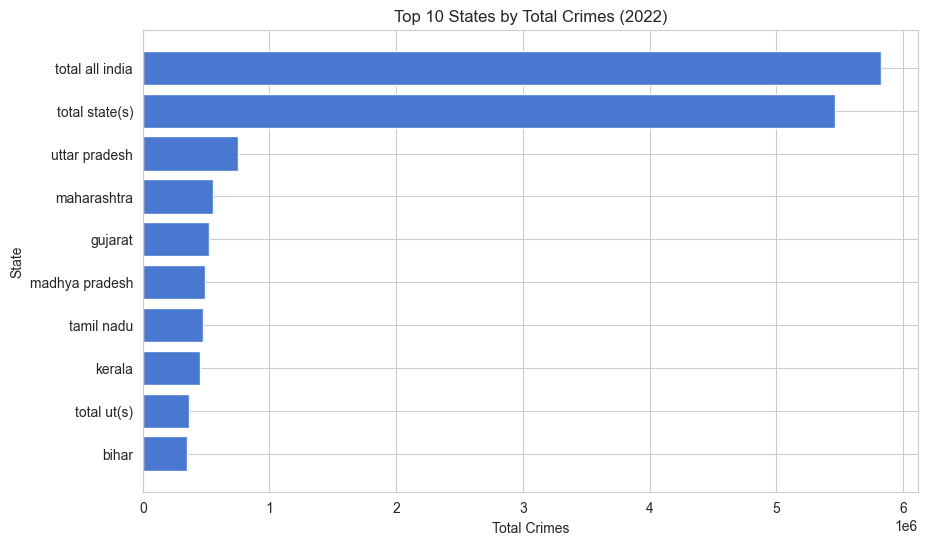

In [33]:
top_states = merged_df.sort_values(
    "Crime_2022", ascending=False
).head(10)

plt.figure(figsize=(10,6))
plt.barh(top_states["State"], top_states["Crime_2022"])
plt.title("Top 10 States by Total Crimes (2022)")
plt.xlabel("Total Crimes")
plt.ylabel("State")
plt.gca().invert_yaxis()
plt.show()


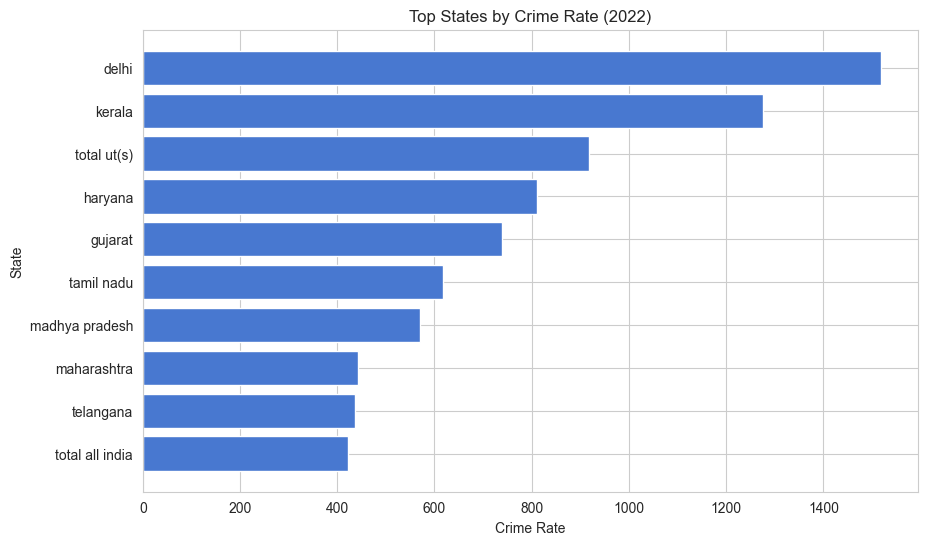

In [34]:
crime_rate_df = merged_df.sort_values(
    "Crime_Rate_2022", ascending=False
).head(10)

plt.figure(figsize=(10,6))
plt.barh(crime_rate_df["State"], crime_rate_df["Crime_Rate_2022"])
plt.title("Top States by Crime Rate (2022)")
plt.xlabel("Crime Rate")
plt.ylabel("State")
plt.gca().invert_yaxis()
plt.show()


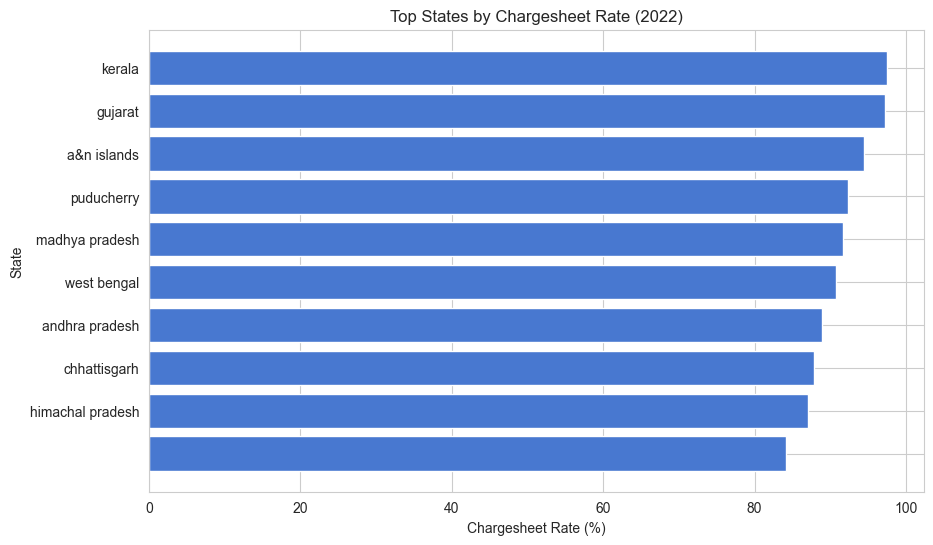

In [35]:
charge_df = merged_df.sort_values(
    "Chargesheet_Rate_2022", ascending=False
).head(10)

plt.figure(figsize=(10,6))
plt.barh(charge_df["State"], charge_df["Chargesheet_Rate_2022"])
plt.title("Top States by Chargesheet Rate (2022)")
plt.xlabel("Chargesheet Rate (%)")
plt.ylabel("State")
plt.gca().invert_yaxis()
plt.show()


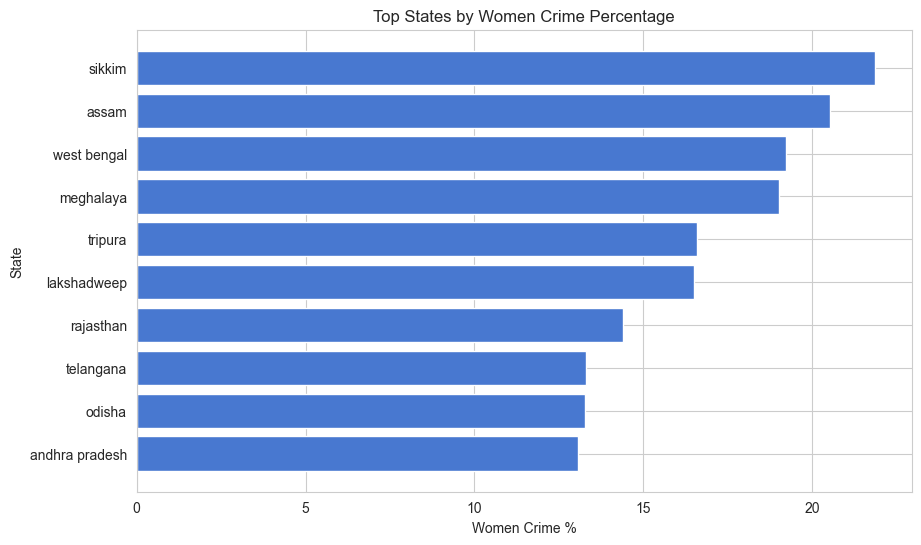

In [36]:
women_df_plot = merged_df.sort_values(
    "Women_Crime_%", ascending=False
).head(10)

plt.figure(figsize=(10,6))
plt.barh(women_df_plot["State"], women_df_plot["Women_Crime_%"])
plt.title("Top States by Women Crime Percentage")
plt.xlabel("Women Crime %")
plt.ylabel("State")
plt.gca().invert_yaxis()
plt.show()


               State  Crime_2020  Crime_2021  Crime_2022  \
0     andhra pradesh    238105.0    222199.0    195284.0   
1  arunachal pradesh      2503.0      3039.0      2761.0   
2              assam    121609.0    133239.0     68937.0   
3              bihar    257512.0    282083.0    347835.0   
4       chhattisgarh    103173.0    110633.0    121065.0   

   Population_Lakh_2022  Crime_Rate_2022  Chargesheet_Rate_2022  \
0                 530.3            368.2                   88.9   
1                  15.5            178.0                   51.9   
2                 354.9            194.2                   34.3   
3                1255.3            277.1                   82.5   
4                 299.5            404.2                   87.9   

   Population_2011  Women_Crime_2022  Women_Crime_%  Crime_per_Population  
0       84580777.0           25503.0      13.059442            368.251933  
1        1383727.0             335.0      12.133285            178.129032  
2       

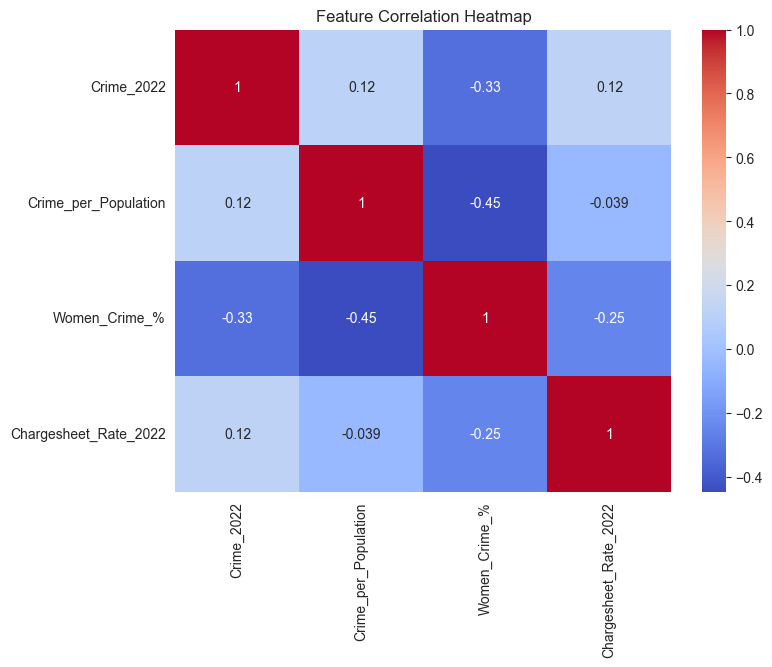

In [37]:
# ===== IMPORTS (IMPORTANT) =====
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ===== CHECK DATA =====
print(merged_df.head())

# ===== CORRELATION HEATMAP =====
plt.figure(figsize=(8,6))

corr = merged_df[[
    "Crime_2022",
    "Crime_per_Population",
    "Women_Crime_%",
    "Chargesheet_Rate_2022"
]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Feature Correlation Heatmap")
plt.show()

## Key Insights
- States with higher crime rates also appear in higher risk categories.
- Women-related crimes contribute noticeably to overall crime patterns.
- Chargesheet rate influences risk prediction in the ML model.
- Crime trends from 2020–2022 show variation across states.


## Predictive Modeling – Crime Risk Classification
A Decision Tree classification model is trained to categorize states into low, medium, and high crime risk levels based on crime statistics and demographic features.


In [38]:
merged_df["Crime_Growth"] = merged_df["Crime_2022"] - merged_df["Crime_2021"]

In [39]:
merged_df["Crime_per_Population"] = merged_df["Crime_Rate_2022"]

merged_df["Women_Crime_%"] = (merged_df["Women_Crime_2022"] / merged_df["Crime_2022"]) * 100

In [40]:
merged_df["Crime_Risk"] = (
    merged_df["Crime_per_Population"] > merged_df["Crime_per_Population"].median()
).astype(int)

In [41]:
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler


features = [
    "Crime_per_Population",
    "Women_Crime_%",
    "Chargesheet_Rate_2022"
]


X = merged_df[features].fillna(0)
y = merged_df["Crime_Risk"]

# ✅ SCALER AFTER IMPORT
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [43]:
# Create Risk Level based on Crime_per_Population

def get_risk(x):
    if x < 200:
        return 0   # Low
    else:
        return 1   # High

merged_df['Risk_Level'] = merged_df['Crime_per_Population'].apply(get_risk)

In [59]:
# Fill missing values with mean
merged_df[features] = merged_df[features].fillna(merged_df[features].mean())

In [60]:
from sklearn.model_selection import train_test_split

X = merged_df[['Crime_per_Population', 'Women_Crime_%', 'Chargesheet_Rate_2022']]
y = merged_df['Risk_Level']  

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [61]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

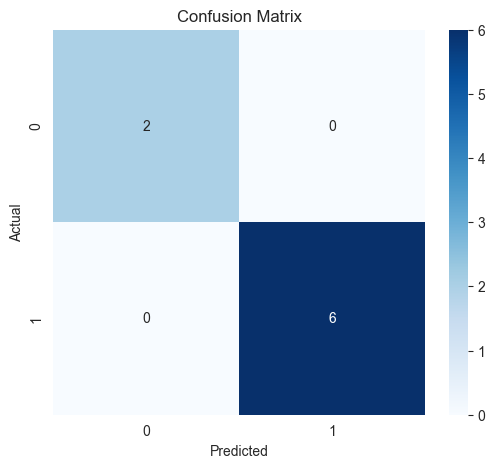

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         6

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



In [62]:

from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=800,
    max_depth=None,
    random_state=42
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print("Accuracy:", accuracy_score(y_test, y_pred))
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))



In [63]:
results = {}
results["Random Forest"] = accuracy_score(y_test, y_pred)

XGBoost Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         6

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



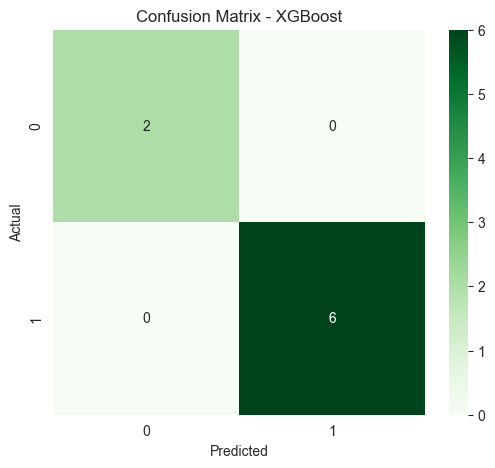

In [64]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

results["XGBoost"] = accuracy_score(y_test, y_pred_xgb)

print("XGBoost Accuracy:", results["XGBoost"])
print(classification_report(y_test, y_pred_xgb))

import seaborn as sns
import matplotlib.pyplot as plt

cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,5))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Feature Importance Analysis
Feature importance is analyzed to understand which variables contribute most to crime risk prediction.


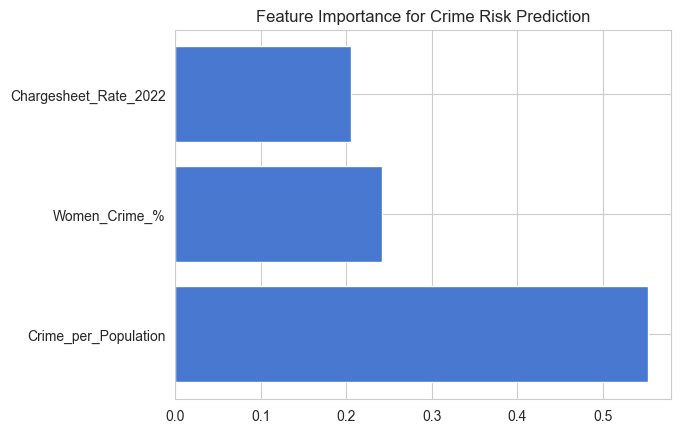

In [65]:
import matplotlib.pyplot as plt

importance = model.feature_importances_

plt.barh(features, importance)
plt.title("Feature Importance for Crime Risk Prediction")
plt.show()


## Interactive Crime Risk Prediction
The trained model is used to predict crime risk levels for user-selected states, demonstrating practical application of the model.


In [66]:
def predict_crime_risk(state_name):
    state_name = state_name.strip().lower()

    row = merged_df[
        merged_df["State"].str.lower() == state_name
    ]

    if row.empty:
        return "State not found"

    X_input = scaler.transform(row[features])
    pred = model.predict(X_input)[0]

    return "High" if pred == 1 else "Low"


In [67]:
print(predict_crime_risk("bihar"))


Low


c:\Users\aayus\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


## Conclusion
This project combines data cleaning, analysis, feature engineering, and machine learning to transform raw crime statistics into actionable insights. The model demonstrates how historical crime patterns can be used to support data-driven decision-making.




<Figure size 640x480 with 0 Axes>

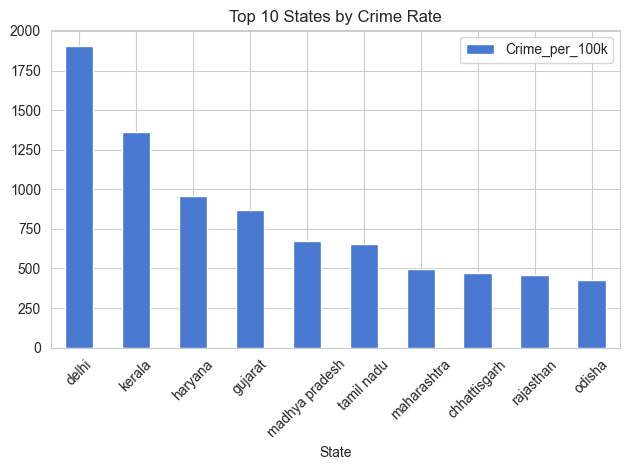

In [68]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("final_project_dataset.csv")  # <-- THIS WAS MISSING

states = df.sort_values("Crime_per_100k", ascending=False).head(10)

plt.figure()
states.plot(x="State", y="Crime_per_100k", kind="bar")
plt.title("Top 10 States by Crime Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

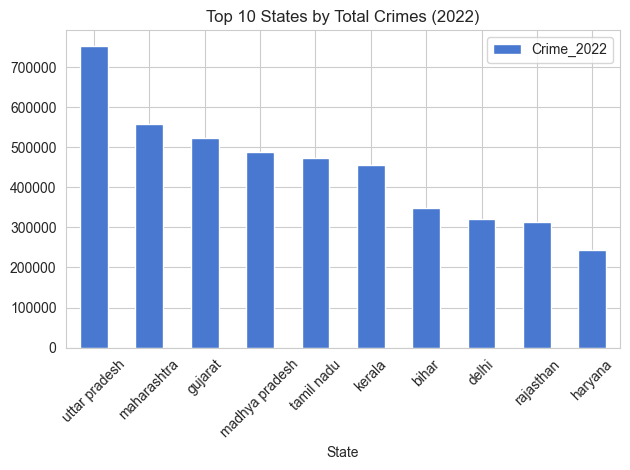

In [69]:
states = df.sort_values("Crime_2022", ascending=False).head(10)

plt.figure()
states.plot(x="State", y="Crime_2022", kind="bar")
plt.title("Top 10 States by Total Crimes (2022)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("top10_total_crime.png", dpi=300)
plt.show()

In [70]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

results = {}

# Random Forest (already done)
results["Random Forest"] = accuracy_score(y_test, y_pred)

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
results["Logistic Regression"] = accuracy_score(y_test, y_pred_lr)

# SVM
svm = SVC()
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
results["SVM"] = accuracy_score(y_test, y_pred_svm)

print("\n--- Model Comparison ---")
for k, v in results.items():
    print(f"{k}: {v:.4f}")


--- Model Comparison ---
Random Forest: 1.0000
Logistic Regression: 1.0000
SVM: 1.0000


In [71]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

# 👉 THIS LINE IS MISSING IN YOUR CASE
results["XGBoost"] = accuracy_score(y_test, y_pred_xgb)

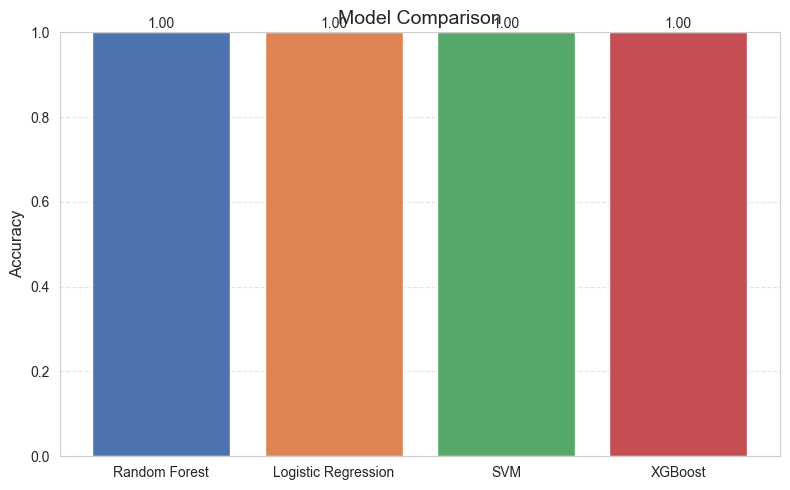

In [72]:
# ===== MODEL COMPARISON GRAPH =====
import matplotlib.pyplot as plt

models = ["Random Forest", "Logistic Regression", "SVM", "XGBoost"]
accuracies = [
    results["Random Forest"],
    results["Logistic Regression"],
    results["SVM"],
    results["XGBoost"]
]

plt.figure(figsize=(8,5))

colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]  

bars = plt.bar(models, accuracies, color=colors)

# value labels on top
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.2f}", ha='center')

plt.title("Model Comparison", fontsize=14)
plt.ylabel("Accuracy", fontsize=12)
plt.ylim(0,1)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

Random Forest, SVM, and XGBoost achieved similar performance (~77.8% accuracy), while Logistic Regression performed comparatively lower, indicating the effectiveness of non-linear and ensemble models for this dataset.

In [ ]:
import pickle
pickle.dump(xgb, open('model/model.pkl', 'wb'))